# Presentation figures

Regenerate every figure used in the accompanying presentation from saved experiment artifacts. This notebook is independent of notebooks 01–05 at runtime: it performs no feature construction or model training and can be run from a fresh kernel after cloning the repository.

The notebook follows the presentation's scientific narrative: first understand the target and available geometric signal, then compare classical baselines, compare the best classical and neural models, and finally test whether their complementary errors support an ensemble. Lower mean absolute error (MAE) is better throughout.

## 1. Setup and artifact contract

The figures depend on the supplied dataset and the saved EDA, classical, final-comparison, and paired-bootstrap artifacts. Missing files produce an actionable workflow error.

The first code cell locates the project root whether the notebook is launched from `MindTheGap/` or `MindTheGap/notebooks/`, then adds that root to Python's import path. The second cell loads only existing data products: target values, molecular metadata, model metrics, per-molecule error-complementarity statistics, and paired-bootstrap results. It creates no features and fits no models.

In [2]:
from pathlib import Path
import sys

project_candidate = Path.cwd().resolve()
if project_candidate.name == "notebooks":
    project_candidate = project_candidate.parent
if str(project_candidate) not in sys.path:
    sys.path.insert(0, str(project_candidate))

In [3]:
from src.config import (
    ADDITIONAL_DIR, CLASSICAL_METRICS, DATA_PATH, PRESENTATION_FIGURE_DIR,
    RESULTS_DIR, TABLE_DIR,
)
from src.data import load_required_csv
from src.presentation import (
    plot_bootstrap_win_probabilities,
    plot_classical_random_models,
    plot_classical_split_comparison,
    plot_ensemble_mae,
    plot_geometry_partial_correlations,
    plot_lightgbm_vs_schnet,
    plot_model_complementarity,
    plot_target_distribution,
)

targets = load_required_csv(
    DATA_PATH, "the supplied datasets/base.csv file",
    usecols=lambda column: column in {"Unnamed: 0", "gap"},
).rename(columns={"Unnamed: 0": "mol_id"})
molecular_metadata = load_required_csv(
    TABLE_DIR / "molecular_metadata.csv", "notebooks/01_preliminary_data_analysis.ipynb"
)
classical_results = load_required_csv(CLASSICAL_METRICS, "notebooks/02_classical_baselines.ipynb")
final_results = load_required_csv(
    RESULTS_DIR / "final_model_comparison.csv", "notebooks/04_final_analysis.ipynb"
)
paired_bootstrap = load_required_csv(
    ADDITIONAL_DIR / "bootstrap_paired_differences.csv",
    "notebooks/05_additional_results_analysis.ipynb",
)
complementarity = load_required_csv(
    ADDITIONAL_DIR / "model_error_complementarity.csv",
    "notebooks/05_additional_results_analysis.ipynb",
)

PRESENTATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Dataset and geometry figures from notebook 1

These are the two plots marked `PPT FIGURE` in notebook 1. They are regenerated here from the supplied target values and the saved molecular-metadata table.

### HOMO–LUMO gap distribution

The upper panel shows the complete labeled-target distribution. Its logarithmic count axis makes both the dense main population and the very rare extreme gaps visible. The long right tail shows that a small number of molecules have gaps far above the typical range.

The lower panel removes only the outer 0.1% for visualization (0.05% from each tail). It reveals the shape of the main population, concentrated around roughly 0.2–0.3 in the dataset's stored units. No observations are removed from any analysis or model; the clipping applies only to this lower display.

/home/ldibari/AQEMIA/MindTheGap/src/plotting.py:34: UserWarning: The figure layout has changed to tight
  figure.tight_layout()


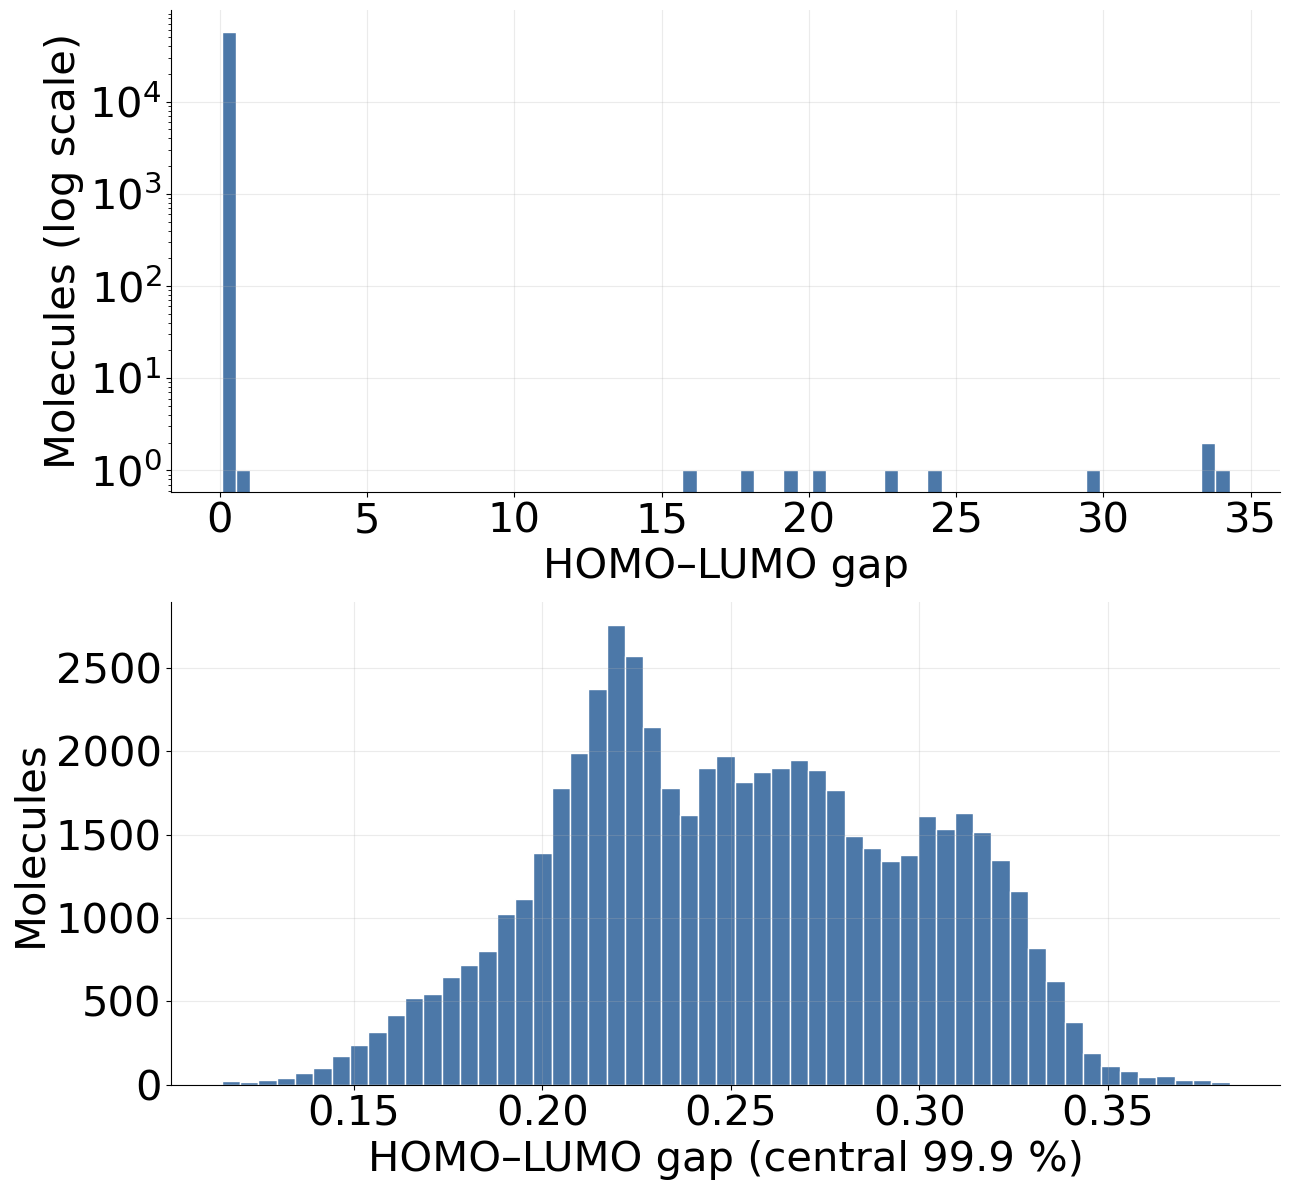

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/target_distribution_vertical.png')

In [4]:
plot_target_distribution(targets["gap"], PRESENTATION_FIGURE_DIR)

### Geometry information beyond molecular size

Each bar is a partial Spearman rank correlation with the HOMO–LUMO gap after controlling for heavy-atom count. Positive bars mean that larger descriptor values tend to accompany larger gaps among similarly sized molecules; negative bars mean the reverse. These are associations, not causal effects.

Coordinate-covariance eigenvalue 1 (about 0.50) and bond-length variability (about 0.47) stand out. The remaining descriptors have weak residual associations (absolute correlations below about 0.10). The main message is therefore that selected aspects of 3D shape and bond-length heterogeneity carry information beyond molecule size, while most individual geometric summaries add little on their own.

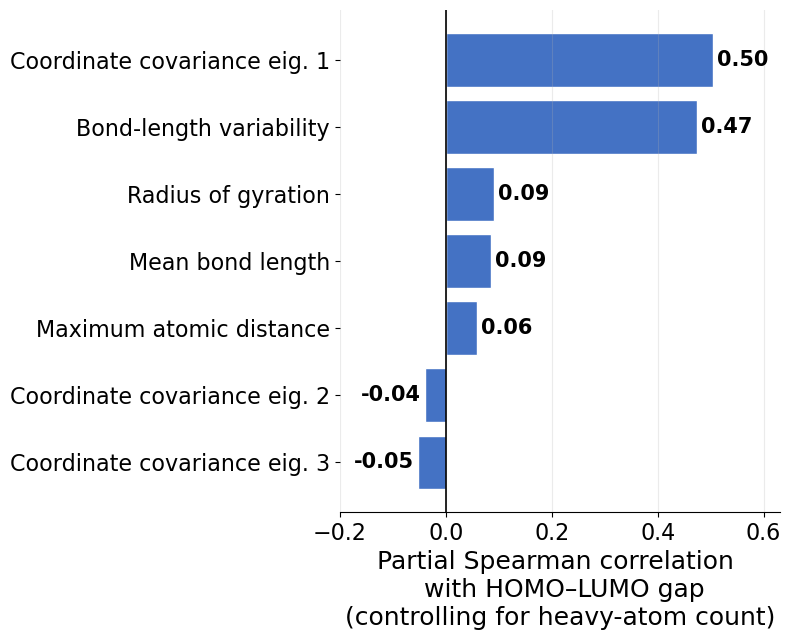

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/geometry_partial_spearman_ppt.png')

In [5]:
plot_geometry_partial_correlations(molecular_metadata, targets, PRESENTATION_FIGURE_DIR)

## 3. Classical baseline comparisons

This section asks two questions: which representation–estimator combination performs best when test molecules resemble the training distribution, and how much performance changes when the split enforces unseen molecular scaffolds?

### Classical models on the random test split

Each horizontal bar is the random-test MAE of one classical baseline; shorter is better. The mean predictor establishes the no-feature reference (0.0434 MAE). Ridge improves when given size/composition or RDKit descriptors, but performs worse than the mean predictor with Morgan fingerprints alone, showing that a representation is not automatically useful with every estimator.

The best classical result is LightGBM with Morgan fingerprints, RDKit 2D descriptors, and simple 3D features (0.0143 MAE). RDKit 2D plus LightGBM is very close (0.0144), so the added fingerprint and simple-geometry features provide only a small random-split gain. This chart compares predictive accuracy, not training cost or model complexity.

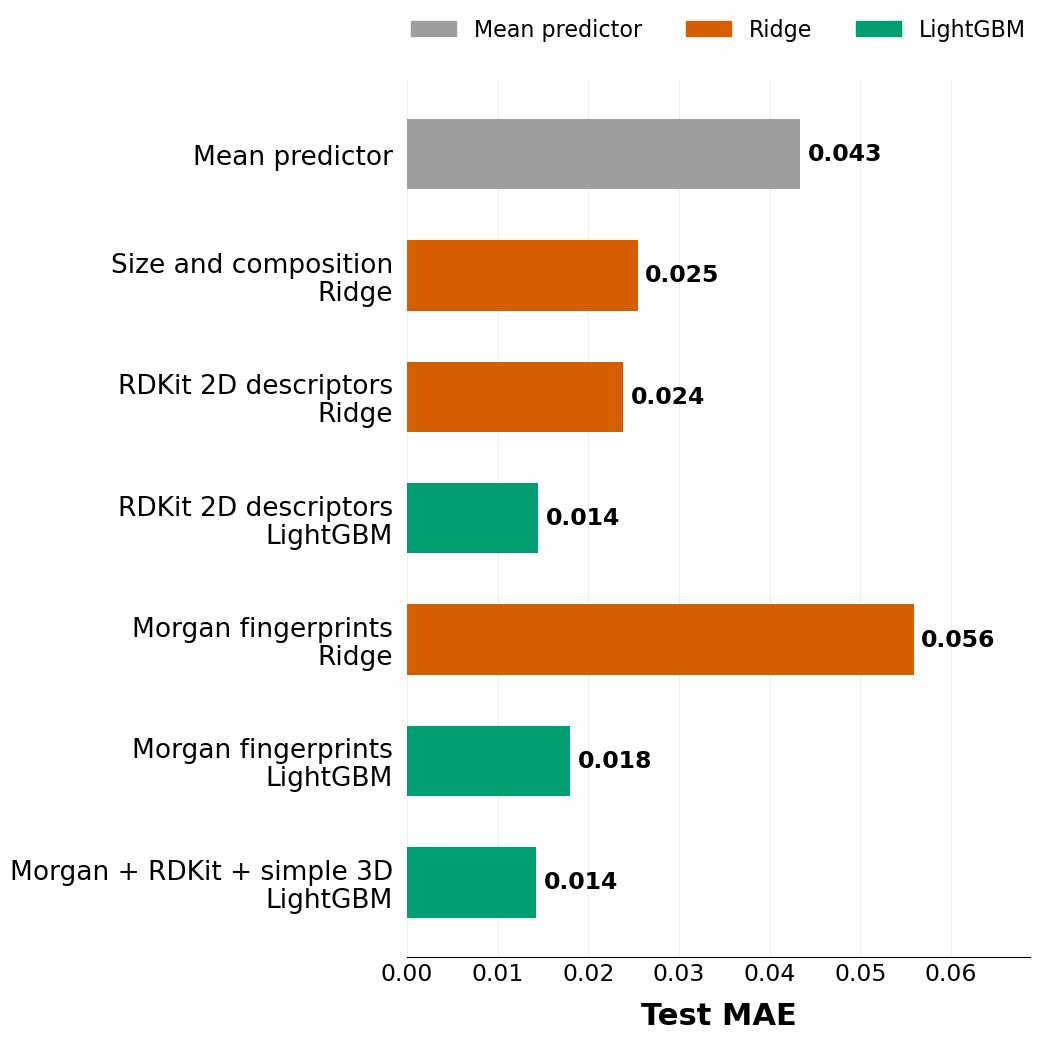

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/random_split_model_comparison.png')

In [6]:
plot_classical_random_models(classical_results, PRESENTATION_FIGURE_DIR)

### Random versus scaffold generalization

For each classical model evaluated under both protocols, the paired bars compare random-test and scaffold-test MAE. The scaffold split groups molecules by Bemis–Murcko scaffold, so its test set is a stronger check of generalization to unfamiliar chemical cores.

All three LightGBM variants degrade on the scaffold test. The strongest combined-feature model rises from 0.0143 to 0.0218 MAE (about 53% higher), while RDKit 2D plus LightGBM reaches 0.0216 and becomes marginally better. The consistent gap between split strategies is evidence that random-split performance is optimistic for scaffold-level extrapolation. Absolute MAE values across the two splits should still be interpreted with care because the test sets differ in both composition and target distribution.

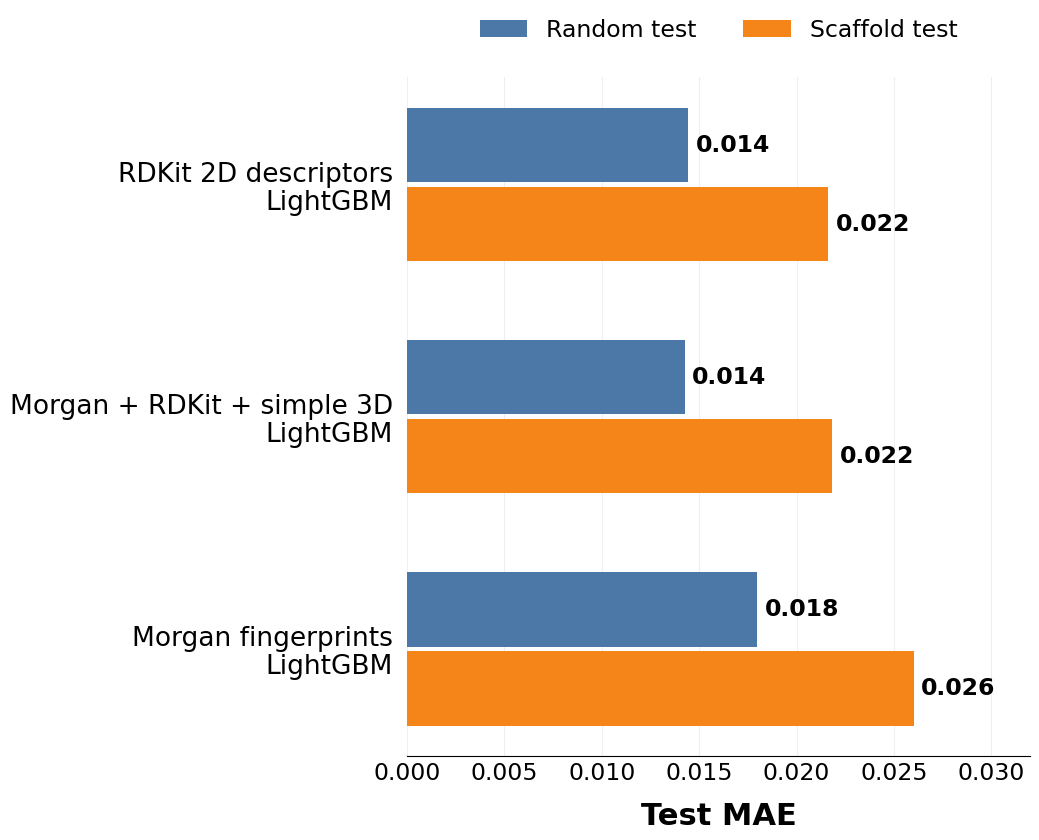

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/random_vs_scaffold_matched_models.png')

In [7]:
plot_classical_split_comparison(classical_results, PRESENTATION_FIGURE_DIR)

## 4. LightGBM and SchNet comparison

The best classical pipeline is now compared with SchNet, which learns directly from atom types and 3D coordinates. Both models use the same fixed train, validation, and test partitions within each split strategy.

### Best classical model versus SchNet

Grouped bars show test MAE for LightGBM and SchNet under random and scaffold splitting. On the random test, LightGBM is slightly better: 0.01426 versus 0.01457 MAE, a difference of about 2.2%. On the scaffold test, the ranking reverses: SchNet reaches 0.01995 versus LightGBM's 0.02182, an improvement of about 8.6%.

The result suggests that engineered 2D/fingerprint features are highly competitive for in-distribution interpolation, whereas SchNet's learned geometric representation transfers better to unseen scaffolds. The chart does not by itself establish why the ranking changes, and it should not be read as a universal claim that one model family is superior.

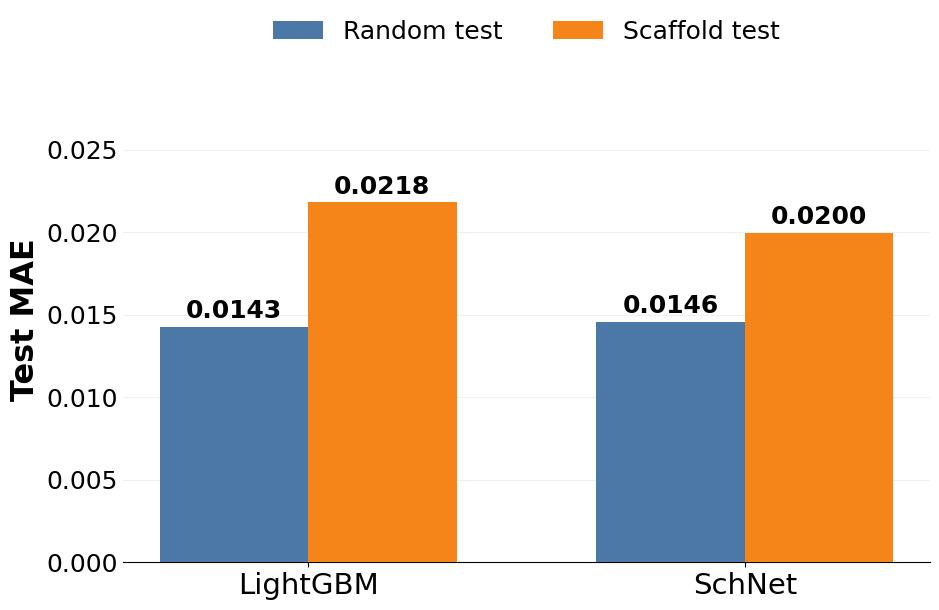

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/01_lightgbm_vs_schnet_mae.png')

In [8]:
plot_lightgbm_vs_schnet(final_results, PRESENTATION_FIGURE_DIR)

### Final ensemble performance

The ensemble combines LightGBM and SchNet predictions with a single weight selected on validation data (`w = 0.46`). Its test MAE is 0.01313 on the random split and 0.01968 on the scaffold split. Relative to LightGBM, these are improvements of about 7.9% and 9.8%, respectively; on the scaffold test it also improves slightly over SchNet alone (about 1.4%).

Because the weight was chosen on validation predictions rather than the test sets, these bars report held-out performance. The larger scaffold MAE again reflects the harder generalization setting and should not be interpreted as an ensemble failure.

Thos figure is not present on the Power Point but is useful for understanding the following ones.

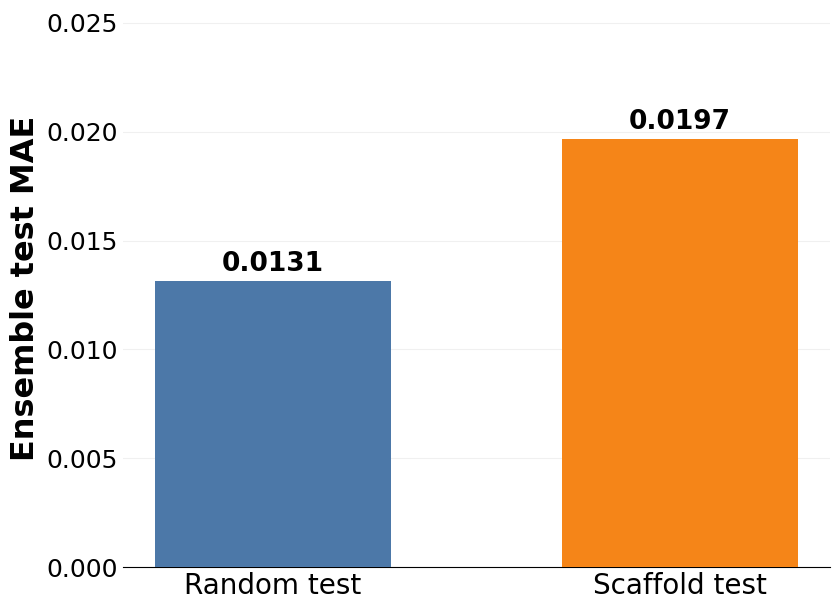

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/02_ensemble_only_mae.png')

In [9]:
plot_ensemble_mae(final_results, PRESENTATION_FIGURE_DIR)

## 5. Model complementarity and paired-bootstrap evidence

An ensemble is useful only if its components make meaningfully different errors. This section first measures that complementarity molecule by molecule, then uses paired bootstrap resampling to quantify whether the observed MAE differences are stable.

### Where LightGBM and SchNet win

The left panel partitions test molecules by which individual model has the lower absolute error. LightGBM wins on 53.3% of random-test molecules, while SchNet wins on 51.6% of scaffold-test molecules. Neither model dominates molecule by molecule, even in the split where it has the better average MAE.

The right panel measures agreement between their errors. Signed-residual Spearman correlations are moderate (0.50 random, 0.57 scaffold), while absolute-error correlations are much lower (0.24 and 0.28). Thus, the models partly agree on over- versus under-prediction but often disagree on which molecules are hardest. This imperfect alignment creates the opportunity for averaging to reduce error. Correlation demonstrates complementarity, not that a particular ensemble rule is optimal.

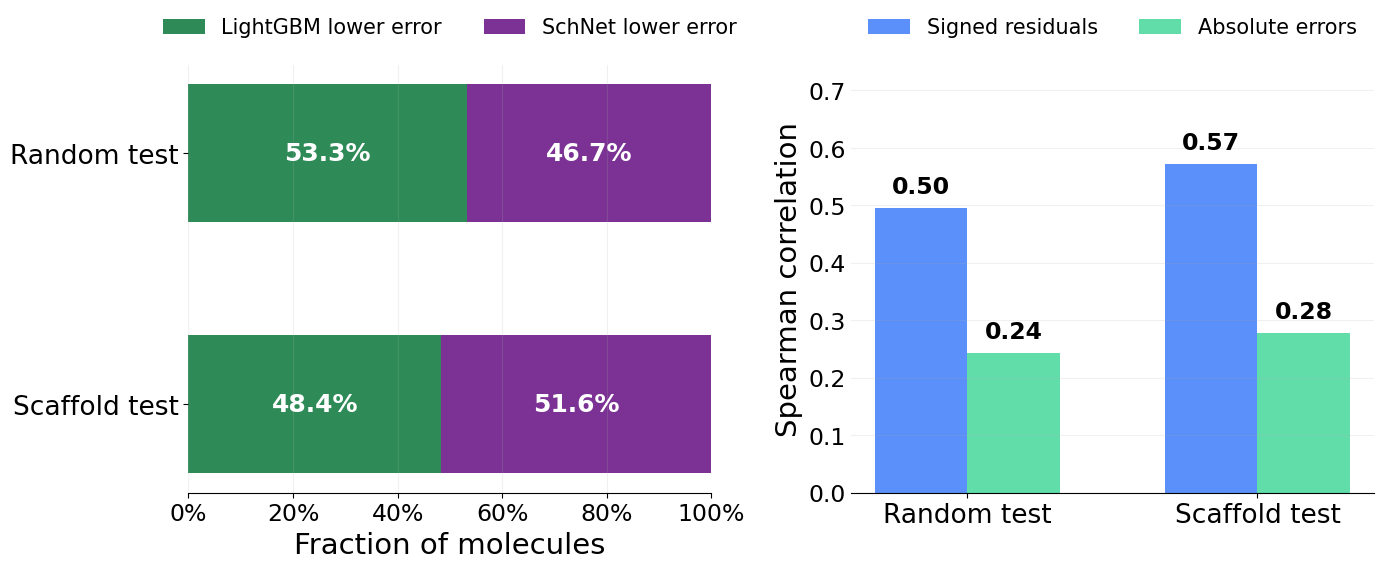

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/model_complementarity_summary_spearman.png')

In [10]:
plot_model_complementarity(complementarity, PRESENTATION_FIGURE_DIR)

### Paired-bootstrap evidence

Each bar is the proportion of paired bootstrap resamples in which the second model in the label achieves lower MAE; 50% would indicate no consistent winner. Pairing preserves the fact that all compared predictions are evaluated on the same test molecules.

On the random split, SchNet beats LightGBM in only 0.4% of resamples, confirming LightGBM's small but stable advantage. On the scaffold split, SchNet wins in 100% of resamples. More importantly, the ensemble beats the best individual model in 100% of random resamples and 99.8% of scaffold resamples. The paired 95% confidence intervals for the ensemble improvement exclude zero in both cases, supporting the conclusion that the ensemble gain is systematic rather than a few-sample fluctuation. These probabilities describe uncertainty for these fixed test sets; they are not posterior probabilities or guarantees on a new dataset.

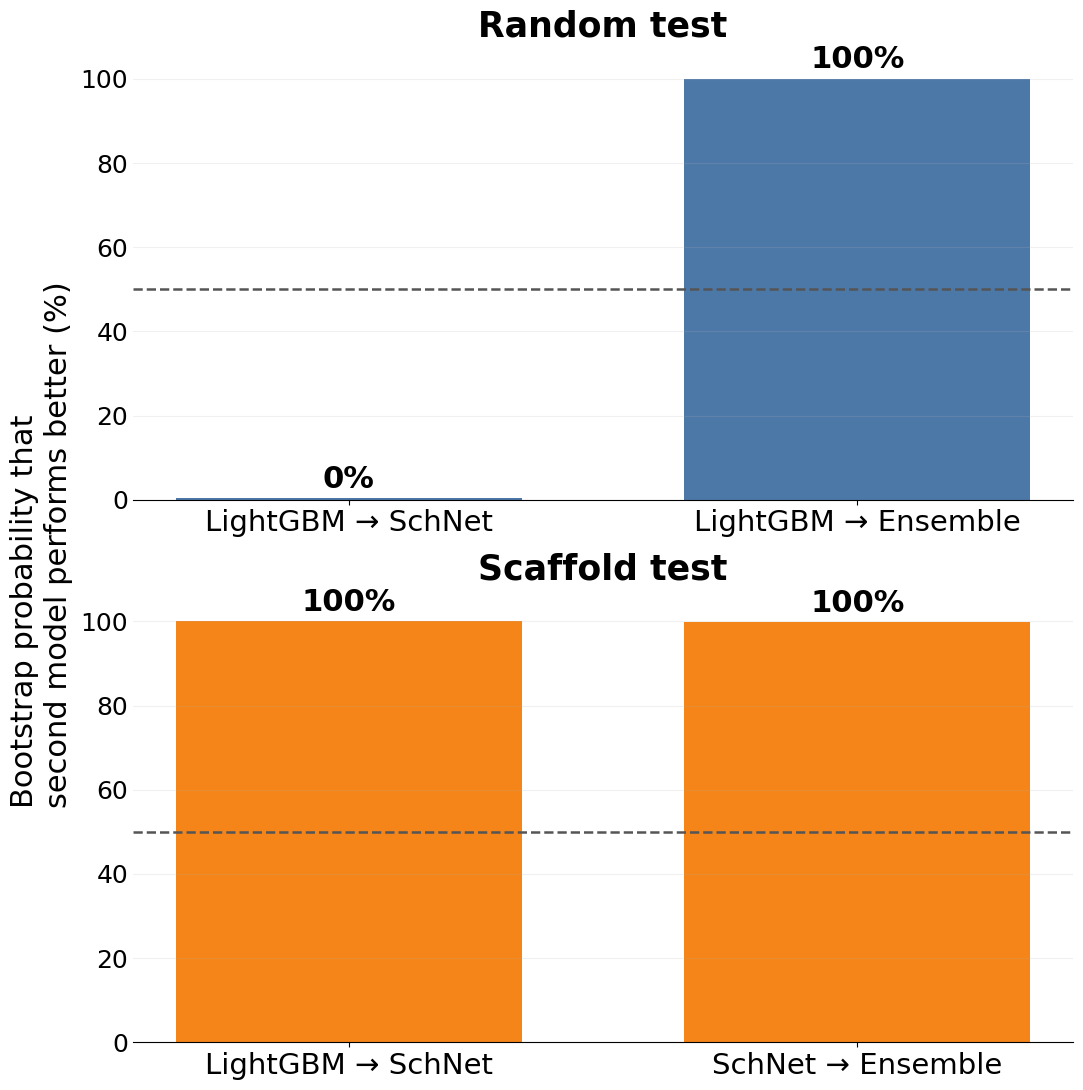

PosixPath('/home/ldibari/AQEMIA/MindTheGap/outputs/presentation_figures/bootstrap_probability_random_scaffold.png')

In [11]:
plot_bootstrap_win_probabilities(paired_bootstrap, PRESENTATION_FIGURE_DIR)

## Output

All presentation assets are written to `outputs/presentation_figures/`. Running this notebook regenerates eight PNG files: two EDA figures, two classical-baseline comparisons, two final-model summaries, one complementarity figure, and one paired-bootstrap figure. Existing files with the same names are replaced.